# Analise Preditiva com Random Forest

By Iasmin Marques

Dados Link da fonte de dados: https://opendatasus.saude.gov.br/dataset/srag-2021-a-2024

Link do repositorio do github https://github.com/iasminimp/srag_tcc

In [3]:
# 🔧 1. Bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# 🔽 2. Suponha que df já está carregado
# Exemplo: df = pd.read_csv('srag.csv')
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

In [11]:
df

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
2,15/01/2024,3,10/01/2024,2,PB,I NRS JOAO PESSOA,1377.0,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,16/01/2024,3,14/01/2024,3,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266427,16/12/2024,51,13/12/2024,50,SP,GVE XXXI SOROCABA,1353.0,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [5]:
# 2. 🔍 Selecionar apenas cura (1) e óbito (2)
df_modelo = df[df['EVOLUCAO'].isin([1, 2])].copy()

In [10]:
df_modelo

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,25/01/2024,4,22/01/2024,4,PR,02RS METROPOLITANA,1356.0,CAMPO LARGO,410420,HOSPITAL INFANTIL DOUTOR WALDEMAR MONASTIER,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6,23/01/2024,4,19/01/2024,3,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,HOSPITAL GERAL DR WALDEMAR ALCANTARA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266424,18/11/2024,47,13/11/2024,46,PR,01RS PARANAGUA,1355.0,PARANAGUA,411820,HOSPITAL REGIONAL DO LITORAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [6]:
# 3. 🧼 Mapear target para 0 e 1
df_modelo['EVOLUCAO'] = df_modelo['EVOLUCAO'].map({1: 0, 2: 1})  # 0 = Cura, 1 = Óbito

# 4. 🎯 Selecionar features binárias relevantes
features = [
    'FEBRE', 'TOSSE', 'DISPNEIA', 'SATURACAO',  # sintomas
    'DIABETES', 'OBESIDADE', 'CARDIOPATI', 'RENAL', 'IMUNODEPRE'  # comorbidades
]

In [12]:
# 4. Remover linhas com código 9 (Ignorado) nas features
mask_valid = ~df_modelo[features].isin([9]).any(axis=1)
df_modelo = df_modelo.loc[mask_valid, :]

In [13]:
# 5. Converter colunas para numérico (usa loc para evitar warning)
df_modelo.loc[:, features] = df_modelo[features].apply(pd.to_numeric, errors='coerce')

In [14]:
# 6. Antes do SMOTE, remover linhas que ainda tenham NaN após a conversão
df_modelo = df_modelo.dropna(subset=features + ['EVOLUCAO'])

In [15]:
# 6. 📦 Separar X e y
X = df_modelo[features]
y = df_modelo['EVOLUCAO']

In [16]:
# 7. ⚖️ Balancear com SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [17]:
# 8. 🔀 Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

In [18]:
# 9. 🌲 Treinar modelo
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
# 10. 📈 Avaliar
y_pred = model.predict(X_test)
print("📊 Classification Report:\n", classification_report(y_test, y_pred))
print("🧩 Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.62      0.64     15848
           1       0.65      0.70      0.67     15847

    accuracy                           0.66     31695
   macro avg       0.66      0.66      0.66     31695
weighted avg       0.66      0.66      0.66     31695

🧩 Matriz de Confusão:
 [[ 9794  6054]
 [ 4810 11037]]


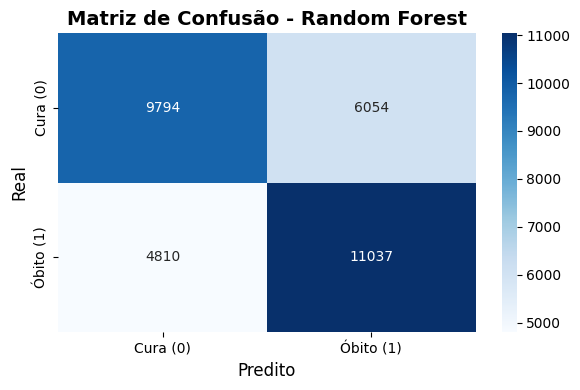

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Rótulos
labels = ['Cura (0)', 'Óbito (1)']

# Visualização
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Matriz de Confusão - Random Forest', fontsize=14, weight='bold')
plt.xlabel('Predito', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()


In [20]:
# 11. 📌 Importância das variáveis
importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

<ipython-input-21-dbc24af31ce6>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='coolwarm')


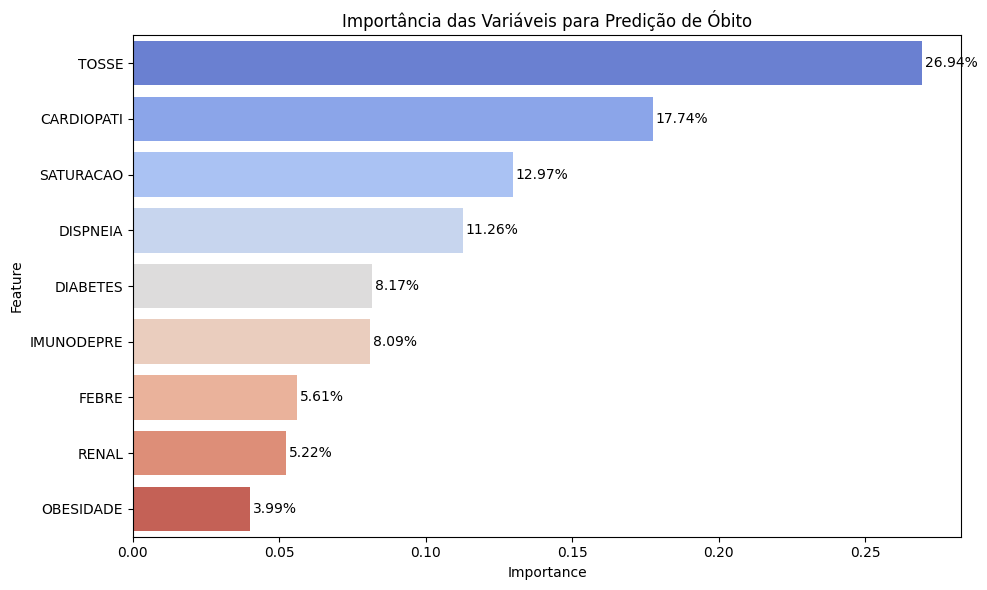

In [21]:
# 12. 📊 Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='coolwarm')
plt.title('Importância das Variáveis para Predição de Óbito')
for i, v in enumerate(importances['Importance']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()

# Resultado





* Esse relatório avalia o desempenho do modelo para cada classe (0 = Cura, 1 = Óbito).

| Métrica       | Classe 0 (Cura) | Classe 1 (Óbito) | Interpretação                                                                                          |
| ------------- | --------------- | ---------------- | ------------------------------------------------------------------------------------------------------ |
| **Precision** | 0.67            | 0.65             | Das previsões feitas como "Cura", 67% estavam corretas. Para "Óbito", 65% estavam corretas.            |
| **Recall**    | 0.62            | 0.70             | O modelo detecta 70% dos casos de óbito corretamente, mas perde 30%. Para cura, acerta 62%.            |
| **F1-score**  | 0.64            | 0.67             | Combinação entre *precision* e *recall*. Ambos valores são razoáveis, com leve vantagem para classe 1. |
| **Accuracy**  | 0.66            | —                | Acerto global: o modelo acerta 66% dos casos no total.                                                 |



O modelo está razoavelmente equilibrado, com bom desempenho em identificar óbitos (recall = 0.70), o que é importante em contextos clínicos, já que não detectar um caso grave (falso negativo) pode ser mais crítico do que um falso positivo.

## Matriz de Confusão


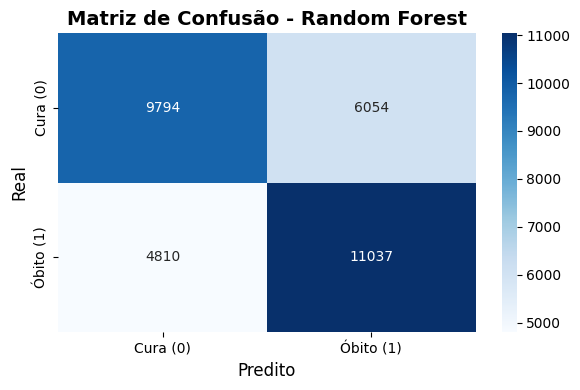

In [25]:
cm = confusion_matrix(y_test, y_pred)

# Rótulos
labels = ['Cura (0)', 'Óbito (1)']

# Visualização
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Matriz de Confusão - Random Forest', fontsize=14, weight='bold')
plt.xlabel('Predito', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()


Interpretação linha a linha:

🔵 Linha 1 - Pacientes com desfecho real = Cura (classe 0):

* 9794 foram corretamente classificados como "Cura" (verdadeiros negativos).

* 6054 foram classificados incorretamente como "Óbito" (falsos positivos).

🔴 Linha 2 - Pacientes com desfecho real = Óbito (classe 1):

* 4810 foram erroneamente classificados como "Cura" (falsos negativos).

* 11037 foram corretamente classificados como "Óbito" (verdadeiros positivos).


## Interpretação da Importância das variaveis na Predição de Óbito


| Variável       | Importância | Interpretação Clínica e Estatística                                                                                                                                                                                                                                               |
| -------------- | ----------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **TOSSE**      | **26,94%**  | 🚨 **Principal variável preditora** no seu modelo. A presença ou ausência de tosse teve o maior peso nas decisões do modelo. Isso pode indicar que a ausência de tosse em casos graves (ex: evolução silenciosa) ou sua presença em conjunto com outros sintomas agrava o quadro. |
| **CARDIOPATI** | **17,74%**  | ❤️ Pacientes com **doença cardíaca** prévia têm maior risco de evolução para óbito. É coerente com a literatura clínica.                                                                                                                                                          |
| **SATURAÇÃO**  | **12,97%**  | 🫁 Baixa saturação de oxigênio é um **marcador de gravidade** e comprometimento respiratório. Altamente relevante.                                                                                                                                                                |
| **DISPNEIA**   | **11,26%**  | 😮‍💨 A falta de ar indica comprometimento pulmonar, e sua presença está associada a casos mais graves.                                                                                                                                                                           |
| **DIABETES**   | **8,17%**   | 🩸 A diabetes reduz a imunidade e é **um dos principais fatores de risco para agravamento de infecções respiratórias**.                                                                                                                                                           |
| **IMUNODEPRE** | **8,09%**   | 🛡️ Pacientes com imunossupressão (ex: câncer, HIV, transplantados) estão naturalmente mais vulneráveis à evolução desfavorável.                                                                                                                                                  |
| **FEBRE**      | **5,61%**   | 🔥 Embora comum, a febre tem **menor poder discriminatório** para óbito isoladamente — por isso a menor importância.                                                                                                                                                              |
| **RENAL**      | **5,22%**   | 💧 Insuficiência renal indica fragilidade clínica geral, associada a maior risco de complicações.                                                                                                                                                                                 |
| **OBESIDADE**  | **3,99%**   | ⚖️ A obesidade é um fator de risco conhecido, mas seu impacto no modelo foi menor comparado aos outros — pode estar correlacionado com outras variáveis (ex: diabetes).                                                                                                           |


### Resumo


* Meu modelo tem bom recall para óbito (0.70), o que é crucial para alertar sobre casos graves.

* A acurácia geral é 66%, o que é aceitável, especialmente considerando o equilíbrio entre classes.

* Ainda existem muitos falsos positivos (6054) e falsos negativos (4810), mas com fine-tuning (ex: ajuste de threshold, modelos mais complexos ou features adicionais), isso pode melhorar.

# Analise Preditiva utilizando mais features
* Utilizando mais features, nesse caso utilizando os fatores de risco e sintomas;

In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

In [28]:
df

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
2,15/01/2024,3,10/01/2024,2,PB,I NRS JOAO PESSOA,1377.0,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,16/01/2024,3,14/01/2024,3,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266427,16/12/2024,51,13/12/2024,50,SP,GVE XXXI SOROCABA,1353.0,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [29]:
# Colunas de interesse
fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]
sintomas = [
    'FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO',
    'DIARREIA', 'VOMITO', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'OUTRO_SIN'
]

In [30]:
# Mapear target: 1-Cura, 2-Óbito
df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})  # 0: Cura, 1: Óbito
df_modelo = df[df['EVOLUCAO'].isin([0, 1])].copy()

In [31]:

# Combinar as features
features = fatores_risco + sintomas

In [32]:
features

['PUERPERA',
 'CARDIOPATI',
 'HEMATOLOGI',
 'SIND_DOWN',
 'HEPATICA',
 'ASMA',
 'DIABETES',
 'NEUROLOGIC',
 'PNEUMOPATI',
 'IMUNODEPRE',
 'RENAL',
 'OBESIDADE',
 'OUT_MORBI',
 'FEBRE',
 'TOSSE',
 'GARGANTA',
 'DISPNEIA',
 'DESC_RESP',
 'SATURACAO',
 'DIARREIA',
 'VOMITO',
 'DOR_ABD',
 'FADIGA',
 'PERD_OLFT',
 'PERD_PALA',
 'OUTRO_SIN']

In [33]:
# Converter para numérico
df_modelo[features] = df_modelo[features].apply(pd.to_numeric, errors='coerce')

In [34]:
# Remover linhas com valores faltantes nas features selecionadas
df_modelo = df_modelo.dropna(subset=features + ['EVOLUCAO'])

In [35]:
# Separar X e y
X = df_modelo[features]
y = df_modelo['EVOLUCAO']

In [53]:
# Balancear com SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [54]:
# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)


In [55]:
# Treinar modelo
modelo = RandomForestClassifier(random_state=42, n_estimators=100)
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [56]:
# Avaliação
y_pred = modelo.predict(X_test)
relatorio = classification_report(y_test, y_pred, output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)

In [57]:
# Importância das features
importancia = pd.DataFrame({
    'feature': features,
    'importancia': modelo.feature_importances_
}).sort_values(by='importancia', ascending=False)

In [58]:
# 10. 📈 Avaliar
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.79      0.80     13785
         1.0       0.80      0.82      0.81     13867

    accuracy                           0.81     27652
   macro avg       0.81      0.81      0.81     27652
weighted avg       0.81      0.81      0.81     27652



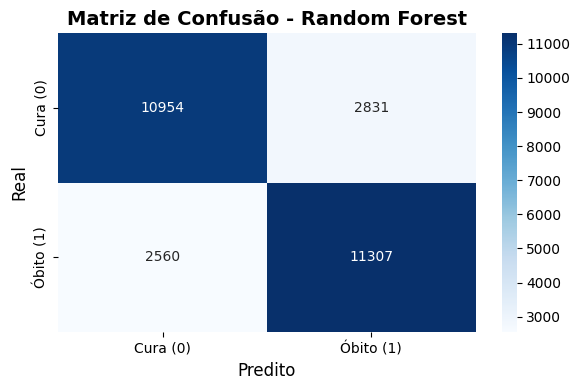

In [61]:
cm = confusion_matrix(y_test, y_pred)

# Rótulos
labels = ['Cura (0)', 'Óbito (1)']

# Visualização
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Matriz de Confusão - Random Forest', fontsize=14, weight='bold')
plt.xlabel('Predito', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()

<ipython-input-60-1a4f724484b9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


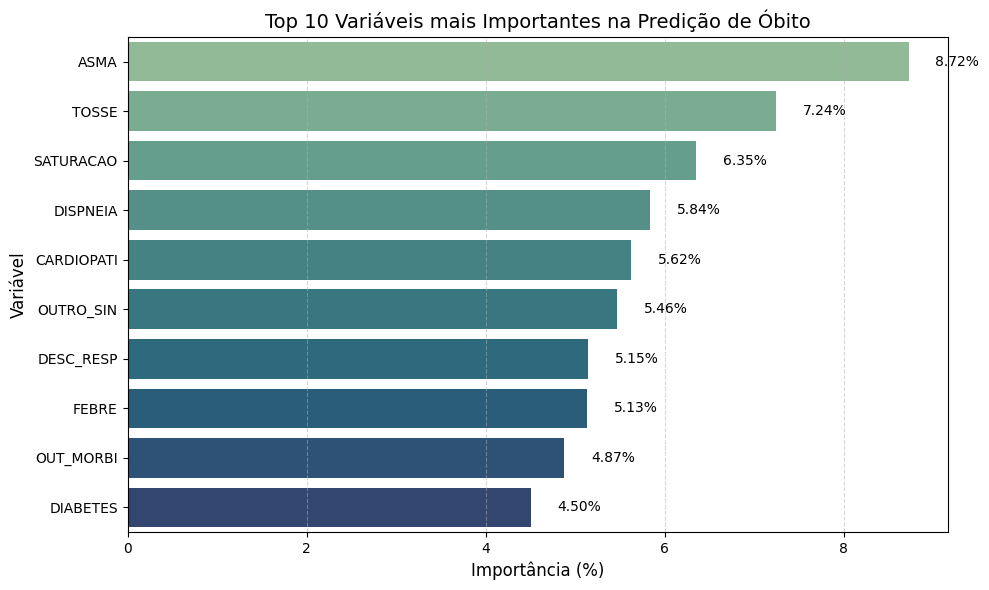

In [60]:
# Selecionar as 10 features mais importantes
importancias_top10 = importancia.head(10).copy()
importancias_top10['importancia_percentual'] = importancias_top10['importancia'] * 100

# 📊 Gráfico de barras com valores
plt.figure(figsize=(10, 6))
sns.barplot(
    x='importancia_percentual',
    y='feature',
    data=importancias_top10,
    palette='crest'
)
plt.title('Top 10 Variáveis mais Importantes na Predição de Óbito', fontsize=14)
plt.xlabel('Importância (%)', fontsize=12)
plt.ylabel('Variável', fontsize=12)

# Adicionar os valores numéricos no gráfico
for i, v in enumerate(importancias_top10['importancia_percentual']):
    plt.text(v + 0.3, i, f"{v:.2f}%", va='center', fontsize=10)

plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


## Interpretação dos Resultados com mais features

*  O modelo está prevendo se o paciente vai evoluir para cura (classe 0) ou óbito (classe 1).

| Classe             | Precisão                                               | Revocação (Recall) | F1-Score | Suporte |
| ------------------ | ------------------------------------------------------ | ------------------ | -------- | ------- |
| **0 (Cura)**       | 81,06%                                                 | 79,46%             | 80,25%   | 13.785  |
| **1 (Óbito)**      | 79,98%                                                 | 81,54%             | 80,75%   | 13.867  |
| **Acurácia Geral** | **80,5%** — Boa performance e relativamente balanceada |                    |          |         |


* O modelo está equilibrado em prever tanto os casos de cura quanto de óbito.

* Precision e recall estão muito próximos para ambas as classes, o que significa que:

* Está cometendo poucos falsos positivos e falsos negativos.

* O F1-score médio de 80% é excelente para um problema real de saúde pública e com dados reais do DataSUS (que costumam ser ruidosos e desbalanceados).


### Matriz confusão

O modelo está fazendo boas previsões nas duas classes com erros razoáveis.

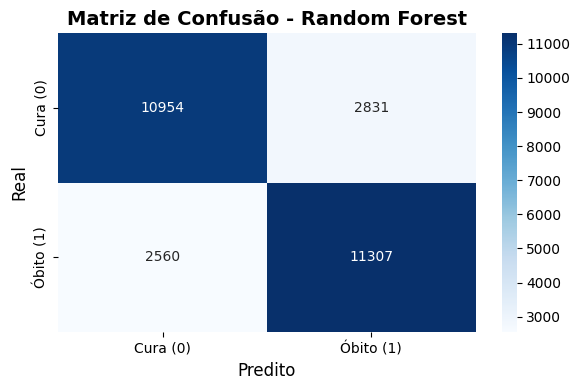

In [52]:
cm = confusion_matrix(y_test, y_pred)

# Rótulos
labels = ['Cura (0)', 'Óbito (1)']

# Visualização
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Matriz de Confusão - Random Forest', fontsize=14, weight='bold')
plt.xlabel('Predito', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()

* Verdadeiros Negativos (Cura correta): 10954

* Falsos Positivos (Predisse Óbito, mas era Cura): 2831

* Falsos Negativos (Predisse Cura, mas era Óbito): 2560

* Verdadeiros Positivos (Óbito correto): 11307

### Interpretação da importancia das features

* Os sintomas respiratórios (TOSSE, DISPNEIA, SATURACAO, DESC_RESP) são fortemente preditivos — coerente com quadros graves de SRAG.

* Doenças crônicas como ASMA, CARDIOPATI e DIABETES também têm peso relevante na predição de óbito.

* O modelo conseguiu combinar sinais clínicos e comorbidades, o que melhorou o desempenho (em relação à análise com apenas sintomas anteriormente).

# Modelo preditivo utilizando mais features
Features: IDADE, SEXO, VACINA_COV, UTI, SUPORT_VEN, etc.



In [ ]:
# vem ai